In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"]=(12,5)

In [4]:
import os
print(os.getcwd())

d:\MutualFundAnalytics\Notebooks


In [5]:
import os
os.chdir("..")
print(os.getcwd())

d:\MutualFundAnalytics


In [6]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv")

nav = pd.read_csv("data/raw/02_nav_history.csv")

transactions = pd.read_csv("data/raw/08_investor_transactions.csv")

portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

In [7]:
fund_master.head()
nav.head()
transactions.head()
portfolio.head()
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [8]:
print(nav.columns)

print(transactions.columns)

print(portfolio.columns)

print(fund_master.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')
Index(['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category',
       'plan', 'launch_date', 'benchmark', 'expense_ratio_pct',
       'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager',
       'risk_category', 'sebi_category_code'],
      dtype='str')


In [9]:
print("Fund Master :", fund_master.shape)
print("NAV :", nav.shape)
print("Transactions :", transactions.shape)
print("Portfolio :", portfolio.shape)
print("Benchmark :", benchmark.shape)

Fund Master : (40, 15)
NAV : (46000, 3)
Transactions : (32778, 13)
Portfolio : (322, 8)
Benchmark : (8050, 3)


In [10]:
print(nav.isnull().sum())

print(transactions.isnull().sum())

print(portfolio.isnull().sum())

amfi_code    0
date         0
nav          0
dtype: int64
investor_id           0
transaction_date      0
amfi_code             0
transaction_type      0
amount_inr            0
state                 0
city                  0
city_tier             0
age_group             0
gender                0
annual_income_lakh    0
payment_mode          0
kyc_status            0
dtype: int64
amfi_code            0
stock_symbol         0
stock_name           0
sector               0
weight_pct           0
market_value_cr      0
current_price_inr    0
portfolio_date       0
dtype: int64


In [11]:
nav['date'] = pd.to_datetime(nav['date'])

transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

portfolio['portfolio_date'] = pd.to_datetime(
    portfolio['portfolio_date']
)

In [12]:
nav = nav.sort_values(
    ['amfi_code','date']
)

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [13]:
nav['daily_return'] = nav.groupby(
    'amfi_code'
)['nav'].pct_change()

nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [14]:
returns = nav.dropna(
    subset=['daily_return']
)

returns.head()

,amfi_code,date,nav,daily_return
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639


In [15]:
var_report = returns.groupby(
    'amfi_code'
)['daily_return'].apply(

    lambda x: np.percentile(x,5)

).reset_index()

var_report.columns = [

    'amfi_code',

    'VaR_95'

]

var_report.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [16]:
def calculate_cvar(x):

    var = np.percentile(x,5)

    cvar = x[x<=var].mean()

    return cvar

In [17]:
cvar_report = returns.groupby(
    'amfi_code'
)['daily_return'].apply(
    calculate_cvar
).reset_index()

cvar_report.columns = [

    'amfi_code',

    'CVaR'

]

cvar_report.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [18]:
risk_report = pd.merge(

    var_report,

    cvar_report,

    on='amfi_code'

)

risk_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [19]:
risk_report = pd.merge(

    risk_report,

    fund_master[
        ['amfi_code','scheme_name']
    ],

    on='amfi_code'

)

risk_report.head()

,amfi_code,VaR_95,CVaR,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [20]:
risk_report = risk_report[

    [

    'amfi_code',

    'scheme_name',

    'VaR_95',

    'CVaR'

    ]

]

risk_report.head()

,amfi_code,scheme_name,VaR_95,CVaR
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [21]:
risk_report.sort_values(

    by='VaR_95'

).head(10)

,amfi_code,scheme_name,VaR_95,CVaR
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [22]:
risk_report.sort_values(

    by='VaR_95',

    ascending=False

).head(10)

,amfi_code,scheme_name,VaR_95,CVaR
27,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000222,-0.000373
5,101208,ABSL Liquid Fund - Regular - Growth,-0.000269,-0.000422
31,120844,Kotak Liquid Fund - Regular - Growth,-0.000285,-0.000411
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
13,118636,Nippon India Gilt Securities Fund - Regular - ...,-0.003804,-0.004919
18,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.003938,-0.005014
12,118635,Nippon India ETF Nifty 50 BeES,-0.012554,-0.016177
6,102885,UTI Nifty 50 Index Fund - Regular - Growth,-0.012613,-0.015490
19,119551,SBI Bluechip Fund - Regular Plan - Growth,-0.012846,-0.016397
28,120841,Kotak Bluechip Fund - Regular - Growth,-0.013142,-0.016363


In [23]:
risk_report.to_csv(

    "Reports/var_cvar_report.csv",

    index=False

)

print("Report Saved Successfully")

Report Saved Successfully


In [24]:
print("Total Schemes :", risk_report.shape[0])

print()

print(risk_report.describe())

Total Schemes : 40

           amfi_code     VaR_95       CVaR
count      40.000000  40.000000  40.000000
mean   120247.000000  -0.014711  -0.018580
std     14534.998667   0.006821   0.008476
min    100016.000000  -0.026859  -0.032459
25%    118632.750000  -0.018394  -0.023133
50%    119551.500000  -0.014376  -0.018185
75%    120842.250000  -0.013247  -0.016572
max    149324.000000  -0.000222  -0.000373


In [25]:
nav = nav.sort_values(['amfi_code','date'])

nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [26]:
top5_funds = nav['amfi_code'].drop_duplicates().head(5)

top5_funds

5750     100016
10350    100025
8050     100033
32200    101206
33350    101207
Name: amfi_code, dtype: int64

In [27]:
sharpe_data = []

for code in top5_funds:

    temp = nav[nav['amfi_code']==code].copy()

    temp = temp.sort_values('date')

    temp['rolling_mean'] = temp['daily_return'].rolling(90).mean()

    temp['rolling_std'] = temp['daily_return'].rolling(90).std()

    temp['Sharpe'] = (
        temp['rolling_mean']
        /
        temp['rolling_std']
    ) * np.sqrt(252)

    sharpe_data.append(temp)

In [28]:
rolling_sharpe = pd.concat(sharpe_data)

rolling_sharpe.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,Sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [29]:
rolling_sharpe[['amfi_code','date','Sharpe']].head(20)

,amfi_code,date,Sharpe
5750,100016,2022-01-03,NaN
5751,100016,2022-01-04,NaN
5752,100016,2022-01-05,NaN
5753,100016,2022-01-06,NaN
5754,100016,2022-01-07,NaN
5755,100016,2022-01-10,NaN
5756,100016,2022-01-11,NaN
5757,100016,2022-01-12,NaN
5758,100016,2022-01-13,NaN
5759,100016,2022-01-14,NaN


In [30]:
rolling_sharpe = rolling_sharpe.merge(

    fund_master[['amfi_code','scheme_name']],

    on='amfi_code',

    how='left'

)

rolling_sharpe.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,Sharpe,scheme_name
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN,HDFC Top 100 Fund - Regular Plan - Growth


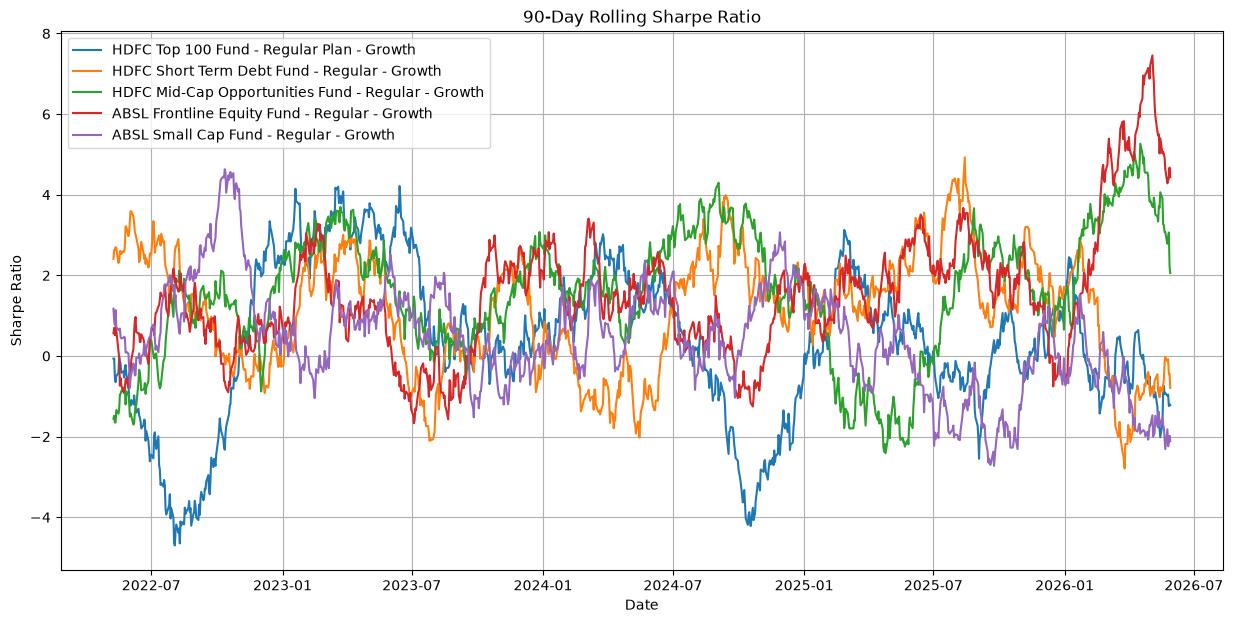

In [31]:
plt.figure(figsize=(15,7))

for code in top5_funds:

    temp = rolling_sharpe[
        rolling_sharpe['amfi_code']==code
    ]

    plt.plot(
        temp['date'],
        temp['Sharpe'],
        label=temp['scheme_name'].iloc[0]
    )

plt.title("90-Day Rolling Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.show()

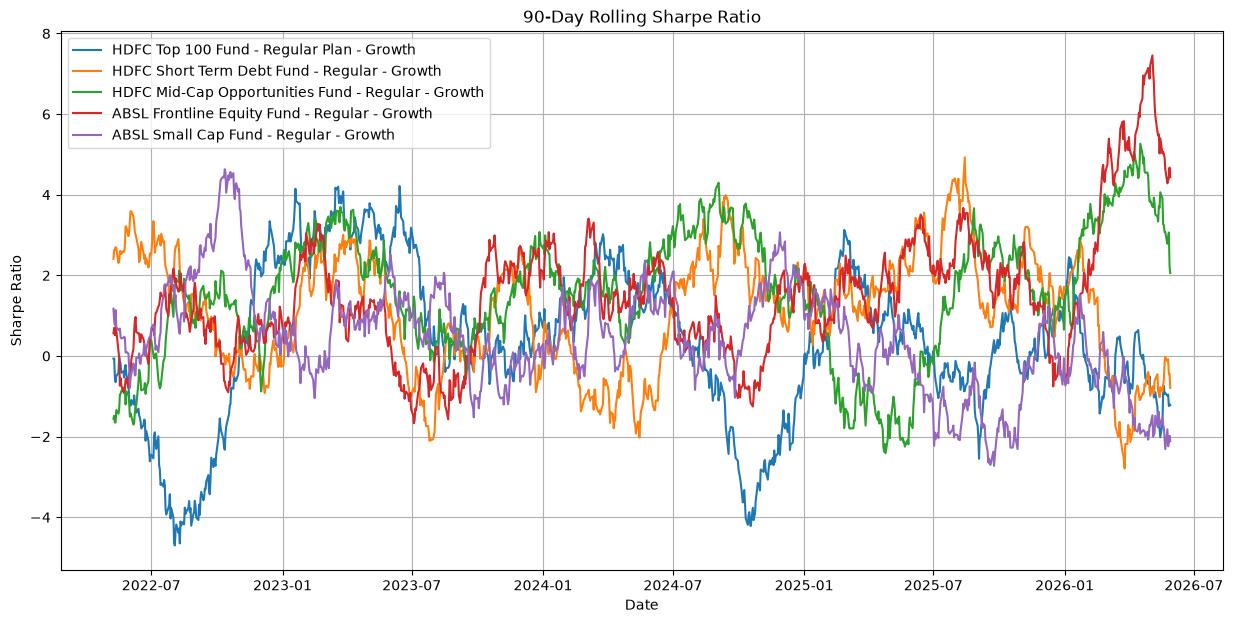

In [32]:
plt.figure(figsize=(15,7))

for code in top5_funds:

    temp = rolling_sharpe[
        rolling_sharpe['amfi_code']==code
    ]

    plt.plot(
        temp['date'],
        temp['Sharpe'],
        label=temp['scheme_name'].iloc[0]
    )

plt.title("90-Day Rolling Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.savefig(

    "Reports/rolling_sharpe_chart.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [33]:
average_sharpe = rolling_sharpe.groupby(

    'scheme_name'

)['Sharpe'].mean().reset_index()

average_sharpe

,scheme_name,Sharpe
0,ABSL Frontline Equity Fund - Regular - Growth,1.484648
1,ABSL Small Cap Fund - Regular - Growth,0.416205
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.586154
3,HDFC Short Term Debt Fund - Regular - Growth,1.125502
4,HDFC Top 100 Fund - Regular Plan - Growth,0.337507


In [34]:
average_sharpe = average_sharpe.sort_values(

    by='Sharpe',

    ascending=False

)

average_sharpe.head(10)

,scheme_name,Sharpe
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.586154
0,ABSL Frontline Equity Fund - Regular - Growth,1.484648
3,HDFC Short Term Debt Fund - Regular - Growth,1.125502
1,ABSL Small Cap Fund - Regular - Growth,0.416205
4,HDFC Top 100 Fund - Regular Plan - Growth,0.337507


In [35]:
average_sharpe.tail(10)

,scheme_name,Sharpe
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.586154
0,ABSL Frontline Equity Fund - Regular - Growth,1.484648
3,HDFC Short Term Debt Fund - Regular - Growth,1.125502
1,ABSL Small Cap Fund - Regular - Growth,0.416205
4,HDFC Top 100 Fund - Regular Plan - Growth,0.337507


In [36]:
average_sharpe.to_csv(

    "Reports/average_sharpe_ratio.csv",

    index=False

)

print("Average Sharpe Report Saved")

Average Sharpe Report Saved


In [37]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [38]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [39]:
transactions['cohort_year'] = transactions[
    'transaction_date'
].dt.year

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [40]:
average_sip = transactions.groupby(
    'cohort_year'
)['amount_inr'].mean().reset_index()

average_sip.columns = [

    'Cohort',

    'Average_SIP'

]

average_sip

,Cohort,Average_SIP
0,2024,107739.476605
1,2025,106704.345527


In [41]:
total_investment = transactions.groupby(
    'cohort_year'
)['amount_inr'].sum().reset_index()

total_investment.columns = [

    'Cohort',

    'Total_Investment'

]

total_investment

,Cohort,Total_Investment
0,2024,2500633252
1,2025,1020947178


In [42]:
investors = transactions.groupby(
    'cohort_year'
)['investor_id'].nunique().reset_index()

investors.columns = [

    'Cohort',

    'Total_Investors'

]

investors

,Cohort,Total_Investors
0,2024,4803
1,2025,4018


In [43]:
cohort_report = average_sip.merge(

    total_investment,

    on='Cohort'

)

cohort_report = cohort_report.merge(

    investors,

    on='Cohort'

)

cohort_report

,Cohort,Average_SIP,Total_Investment,Total_Investors
0,2024,107739.476605,2500633252,4803
1,2025,106704.345527,1020947178,4018


In [44]:
cohort_report.to_csv(

    "Reports/cohort_report.csv",

    index=False

)

print("Cohort Report Saved")

Cohort Report Saved


In [45]:
fund_preference = transactions.groupby(

    ['cohort_year','amfi_code']

).size().reset_index(name='Transactions')

fund_preference.head()

,cohort_year,amfi_code,Transactions
0,2024,100016,584
1,2024,100025,563
2,2024,100033,559
3,2024,101206,585
4,2024,101207,607


In [46]:
fund_preference = fund_preference.merge(

    fund_master[

        ['amfi_code','scheme_name']

    ],

    on='amfi_code'

)

fund_preference.head()

,cohort_year,amfi_code,Transactions,scheme_name
0,2024,100016,584,HDFC Top 100 Fund - Regular Plan - Growth
1,2024,100025,563,HDFC Short Term Debt Fund - Regular - Growth
2,2024,100033,559,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,2024,101206,585,ABSL Frontline Equity Fund - Regular - Growth
4,2024,101207,607,ABSL Small Cap Fund - Regular - Growth


In [47]:
top_funds = fund_preference.sort_values(

    'Transactions',

    ascending=False

).groupby(

    'cohort_year'

).head(1)

top_funds

,cohort_year,amfi_code,Transactions,scheme_name
24,2024,120504,625,ICICI Pru Bluechip Fund - Direct - Growth
59,2025,119551,271,SBI Bluechip Fund - Regular Plan - Growth


In [48]:
top_funds.to_csv(

    "Reports/top_fund_preference.csv",

    index=False

)

print("Top Fund Report Saved")

Top Fund Report Saved


In [49]:
transactions = transactions.sort_values(

    ['investor_id','transaction_date']

)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2025
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024


In [50]:
transactions = transactions.sort_values(

    ['investor_id','transaction_date']

)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2025
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024


In [52]:
print(transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_year']


In [53]:
transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2025
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2025
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024


In [54]:
transactions["transaction_date"] = pd.to_datetime(transactions['transaction_date'])
transactions = transactions.sort_values(['investor_id', 'transaction_date'])
transactions['gap_days']=(
    transactions.groupby('investor_id')
    ['transaction_date']
    .diff()
    .dt.days
)

In [55]:
average_gap = transactions.groupby(

    'investor_id'

)['gap_days'].mean().reset_index()

average_gap.columns = [

    'Investor',

    'Average_Gap'

]

average_gap.head()

,Investor,Average_Gap
0,INV000001,38.000
1,INV000002,82.800
2,INV000003,238.000
3,INV000004,53.375
4,INV000005,52.000


In [56]:
risk_investors = transactions[

    transactions['gap_days'] > 35

]

risk_investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2025,71.0
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,69.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2025,112.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2025,114.0


In [57]:
risk_summary = risk_investors.groupby(

    'investor_id'

).size().reset_index(name='Missed_SIPs')

risk_summary.head()

,investor_id,Missed_SIPs
0,INV000001,1
1,INV000002,4
2,INV000003,1
3,INV000004,3
4,INV000005,2


In [58]:
risk_summary.to_csv(

    "Reports/at_risk_investors.csv",

    index=False

)

print("At Risk Report Saved")

At Risk Report Saved


In [59]:
print(

    "Total At Risk Investors :",

    risk_summary.shape[0]

)

Total At Risk Investors : 4527


In [60]:
average_gap.sort_values(

    by='Average_Gap',

    ascending=False

).head(10)

,Investor,Average_Gap
367,INV000368,509.0
1326,INV001327,501.0
3862,INV003863,471.0
4745,INV004746,458.0
4421,INV004422,458.0
252,INV000253,458.0
2888,INV002889,452.0
2455,INV002456,448.0
4534,INV004535,446.0
1424,INV001425,445.0


In [61]:
portfolio.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [62]:
portfolio["weight_square"] = portfolio["weight_pct"] ** 2

In [63]:
hhi = portfolio.groupby(
    "amfi_code"
)["weight_square"].sum().reset_index()

hhi.columns = [
    "amfi_code",
    "HHI"
]

hhi.head()

,amfi_code,HHI
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


In [64]:
hhi = hhi.merge(

    fund_master[
        [
            "amfi_code",
            "scheme_name",
            "category"
        ]
    ],

    on="amfi_code"

)

hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,1395.3386,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,1475.9226,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,1293.3173,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [65]:
equity = hhi[
    hhi["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
]

equity.head()

,amfi_code,HHI,scheme_name,category
0,100016,1395.3386,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,1475.9226,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,1293.3173,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [66]:
equity.sort_values(

    by="HHI",

    ascending=False

).head(10)

,amfi_code,HHI,scheme_name,category
11,119092,2064.4767,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,1747.5096,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,1682.9820,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,1679.2973,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,1575.7036,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,1537.9360,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,1524.1398,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,1496.8035,Kotak Bluechip Fund - Regular - Growth,Equity


In [67]:
equity.sort_values(

    by="HHI"

).head(10)

,amfi_code,HHI,scheme_name,category
17,119598,1073.4895,SBI Small Cap Fund - Regular Plan - Growth,Equity
16,119552,1080.1069,SBI Bluechip Fund - Direct Plan - Growth,Equity
9,118634,1083.5772,Nippon India Small Cap Fund - Regular - Growth,Equity
20,120504,1086.7415,ICICI Pru Bluechip Fund - Direct - Growth,Equity
14,119095,1096.0535,Axis Small Cap Fund - Regular - Growth,Equity
5,102886,1146.9284,UTI Mid Cap Fund - Regular - Growth,Equity
33,149324,1186.7710,DSP Small Cap Fund - Regular - Growth,Equity
15,119551,1187.1552,SBI Bluechip Fund - Regular Plan - Growth,Equity
8,118633,1214.6086,Nippon India Large Cap Fund - Direct - Growth,Equity
24,120842,1274.3881,Kotak Emerging Equity Fund - Regular - Growth,Equity


In [68]:
equity.to_csv(

    "Reports/equity_hhi_report.csv",

    index=False

)

print("HHI Report Saved")

HHI Report Saved


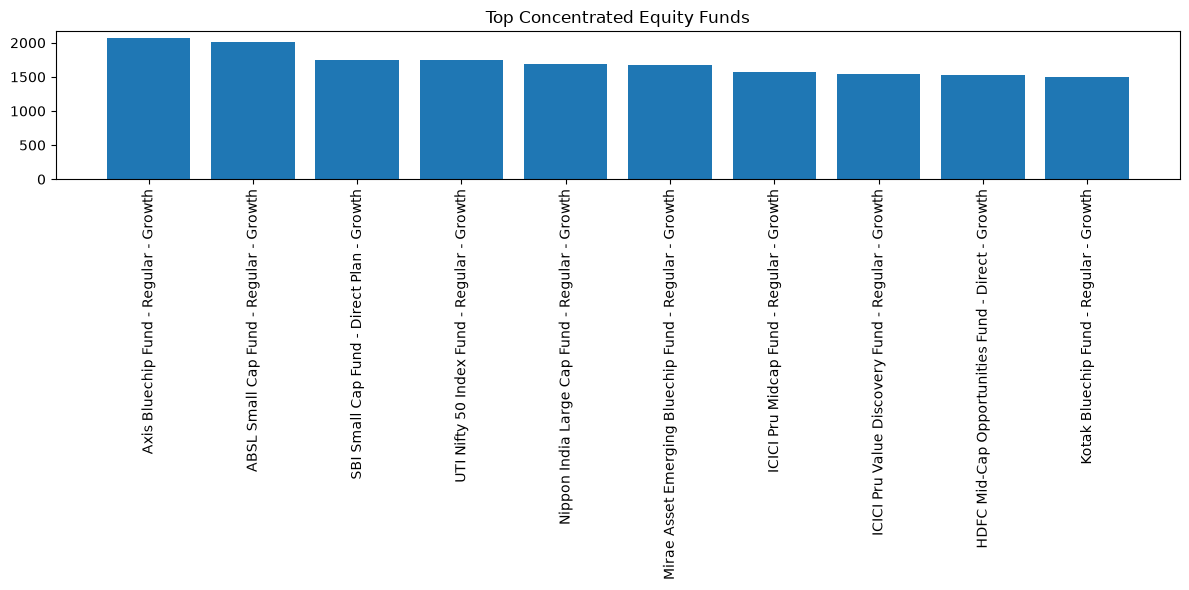

In [69]:
top10 = equity.sort_values(

    by="HHI",

    ascending=False

).head(10)

plt.figure(figsize=(12,6))

plt.bar(

    top10["scheme_name"],

    top10["HHI"]

)

plt.xticks(rotation=90)

plt.title(

    "Top Concentrated Equity Funds"

)

plt.tight_layout()

plt.savefig(

    "Reports/hhi_chart.png",

    dpi=300

)

plt.show()

# Advanced Business Insights

### 1

Historical VaR analysis shows which mutual funds have the highest downside risk.

### 2

Funds with higher Rolling Sharpe Ratio generated better risk-adjusted returns.

### 3

Investor Cohort Analysis identified the year with the highest investment activity.

### 4

SIP Continuity Analysis detected investors with gaps greater than 35 days who may require follow-up.

### 5

HHI analysis identified highly concentrated equity portfolios, indicating higher concentration risk.